# 2PLM with Stan

2 parameters logistic model (2PLM)

$$
P(u_{ij} = 1) = \frac{1}{1+ \exp(-D a_j ( \theta_i - b_j))}
$$

- $\theta_i$: ability of respondent $i$
- $a_j$: discrimination parameter of item $j$
- $b_j$: difficulty parameter of item $j$
- $D = 1.7$: scaling constant

## Priors

$$
\theta_i \sim \mathcal{N}(0, 1), \quad
a_j \sim \text{LogNormal}(0, 0.5), \quad
b_j \sim \mathcal{N}(0, 1)
$$

Fixing $\theta \sim \mathcal{N}(0,1)$ resolves the location/scale non-identifiability of IRT models.

In [1]:
import nest_asyncio
nest_asyncio.apply()

import numpy as np
import matplotlib.pyplot as plt
import stan
import arviz as az

/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/clikit/utils/string.py:81: SyntaxWarning: invalid escape sequence '\s'
  words = re.split("\s+", string)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/clikit/api/args/format/command_option.py:47: SyntaxWarning: invalid escape sequence '\-'
  if not re.match("^[a-zA-Z0-9\-]+$", alias):
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Data Generation

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items
D = 1.7  # scaling constant

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
b_true = rng.normal(0, 1, J)

# Generate responses
logit_p = D * a_true[None, :] * (theta_true[:, None] - b_true[None, :])
p = 1 / (1 + np.exp(-logit_p))
Y = rng.binomial(1, p).astype(int)

print(f"Response matrix shape: {Y.shape}")
print(f"Mean correct rate: {Y.mean():.3f}")
print(f"True a range: [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b range: [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape: (100, 20)
Mean correct rate: 0.463
True a range: [0.42, 2.23]
True b range: [-1.47, 2.91]


## Stan Model

In [3]:
model_code = """
data {
  int<lower=1> N;
  int<lower=1> J;
  array[N, J] int<lower=0, upper=1> Y;
}
parameters {
  vector[N] theta;
  vector<lower=0>[J] a;
  vector[J] b;
}
model {
  theta ~ normal(0, 1);
  a ~ lognormal(0, 0.5);
  b ~ normal(0, 1);

  for (i in 1:N) {
    Y[i] ~ bernoulli_logit(1.7 * a .* (theta[i] - b));
  }
}
"""

## Compile and Sample

Compilation takes ~30 seconds on first run.

In [4]:
data_dict = {"N": N, "J": J, "Y": Y.tolist()}

posterior = stan.build(model_code, data=data_dict, random_seed=42)
fit = posterior.sample(num_chains=4, num_samples=1000, num_warmup=1000)

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7495c6c5a4c0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7495c6c5a4c0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7495c6c5a4c0> is already entered
Exception in callback Task.__step()
h

Building: 0.1s
Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.8s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.4s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.0s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.2s
Building: 4.3s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 

In file included from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_ccdf_log.hpp:5,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob.hpp:331,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/prim.hpp:16,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:16,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/mitama/.cache/httpstan/4.13.0/models/7fqqc2om/model_7fqqc2om.cpp:2:
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/ma

Building: 6.5s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 7.0s
Building: 7.1s
Building: 7.2s
Building: 7.3s
Building: 7.4s
Building: 7.5s


In file included from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:10:
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [with Traits = tbb::interface5::concurrent_unordered_map_traits<std::pair<std::basic_string<char>, std::thread::id>, stan::math::profile_info, tbb::interface5::internal::hash_compare<std::pair<std::basic_string<char>, s

Building: 7.6s
Building: 7.7s
Building: 7.8s
Building: 7.9s
Building: 8.0s
Building: 8.1s
Building: 8.2s
Building: 8.3s
Building: 8.4s
Building: 8.5s
Building: 8.6s
Building: 8.7s
Building: 8.8s
Building: 8.9s
Building: 9.0s
Building: 9.1s
Building: 9.2s
Building: 9.3s
Building: 9.4s
Building: 9.5s
Building: 9.6s
Building: 9.7s
Building: 9.8s
Building: 10.0s
Building: 10.1s
Building: 10.2s
Building: 10.3s
Building: 10.4s
Building: 10.5s
Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building: 11.7s
Building: 11.8s
Building: 11.9s
Building: 12.0s
Building: 12.1s
Building: 12.2s
Building: 12.3s
Building: 12.4s
Building: 12.5s
Building: 12.6s
Building: 12.7s
Building: 12.8s
Building: 12.9s
Building: 13.0s
Building: 13.1s
Building: 13.3s
Building: 13.4s
Building: 13.5s
Building: 13.6s
Building: 13.7s
Building: 13.8s
Building: 13.9s
Building: 14.0s
Building: 14.1s

Building: 19.6s, done.
Sampling:   0%
Sampling:   1% (100/8000)
Sampling:   2% (200/8000)
Sampling:   4% (300/8000)
Sampling:   5% (400/8000)
Sampling:   9% (700/8000)
Sampling:  12% (1000/8000)
Sampling:  18% (1400/8000)
Sampling:  22% (1800/8000)
Sampling:  28% (2200/8000)
Sampling:  32% (2600/8000)
Sampling:  38% (3000/8000)
Sampling:  41% (3300/8000)
Sampling:  56% (4500/8000)
Sampling:  71% (5700/8000)
Sampling:  85% (6800/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 0.000514 seconds
  1000 transitions using 10 leapfrog steps per transition would take 5.14 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.00058 seconds
  1000 transitions using 10 leapfrog steps per transition would take 5.8 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 0.000545 seconds
  1000 transitions using 10 leapfrog steps per transition would take 5.45 seconds.
  Adjus

## Results

In [5]:
idata = az.from_pystan(fit)
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.20,0.30,0.65,1.74,0.00,0.01,3936.07,3126.78,1.0
a[1],1.87,0.54,0.98,2.84,0.01,0.01,3051.02,3108.68,1.0
a[2],0.54,0.14,0.27,0.81,0.00,0.00,4299.87,2748.53,1.0
a[3],1.60,0.52,0.77,2.61,0.01,0.01,2985.29,2555.72,1.0
a[4],0.62,0.16,0.34,0.91,0.00,0.00,4030.91,3351.05,1.0
a[5],0.85,0.21,0.47,1.24,0.00,0.00,4198.49,3054.59,1.0
a[6],0.75,0.19,0.43,1.10,0.00,0.00,4033.49,3305.56,1.0
a[7],1.27,0.32,0.71,1.86,0.01,0.01,3857.58,3312.79,1.0
a[8],1.21,0.30,0.69,1.80,0.00,0.01,3657.91,3052.93,1.0
a[9],0.64,0.16,0.34,0.93,0.00,0.00,4154.24,2876.75,1.0


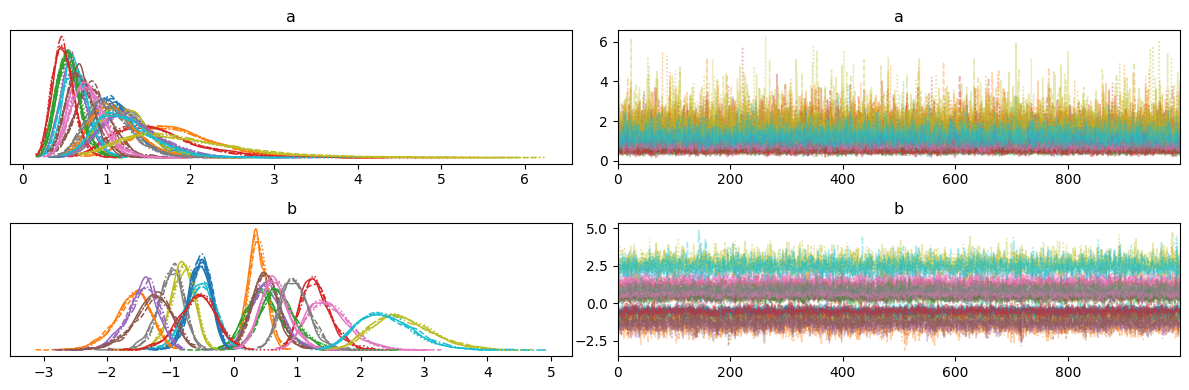

In [6]:
az.plot_trace(idata, var_names=["a", "b"], compact=True)
plt.tight_layout()
plt.show()

## Comparison: Estimated vs True Parameters

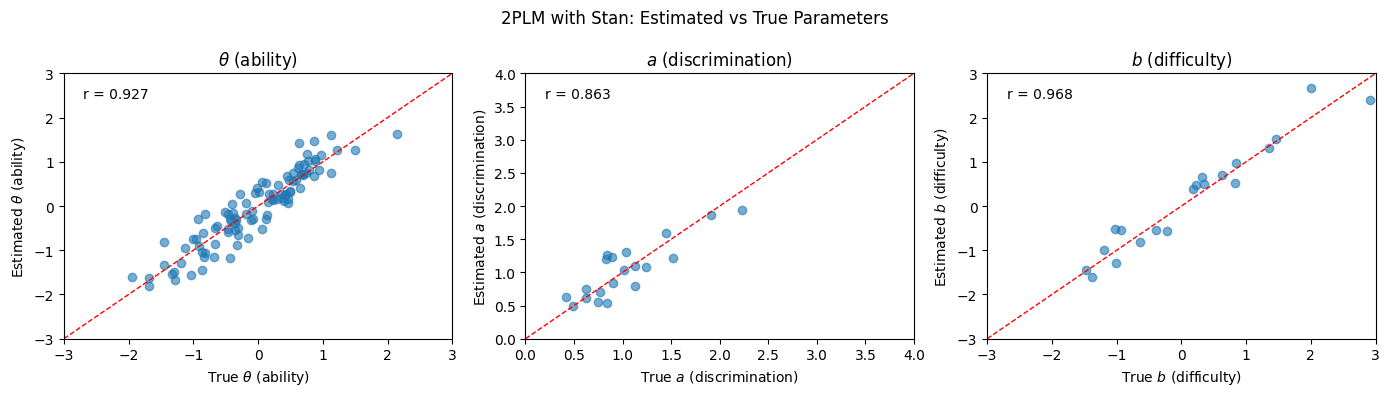

In [7]:
theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values
a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values
b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, true_vals, est_vals, label, lim in zip(
    axes,
    [theta_true, a_true, b_true],
    [theta_est, a_est, b_est],
    [r"$\theta$ (ability)", r"$a$ (discrimination)", r"$b$ (difficulty)"],
    [(-3, 3), (0, 4), (-3, 3)],
):
    ax.scatter(true_vals, est_vals, alpha=0.6)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Estimated {label}")
    ax.set_title(label)
    corr = np.corrcoef(true_vals, est_vals)[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, va="top")

plt.suptitle("2PLM with Stan: Estimated vs True Parameters")
plt.tight_layout()
plt.show()